### Importando as bibliotecas

In [221]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

### Carregando os dados

In [222]:
stats_df = pd.read_csv('..\\data\\player-stats-clean.csv')

In [223]:
stats_df.head(5)

,Player,Nation,Pos,Squad,Born,MP,Starts,Min,Gls,Ast,...,CrdR,2CrdY,Fls,Fld,Off,Crs,Int,TklW,OG,90s
0,Abner,br BRA,DF,Juventude,2004,19,13,1318,0,1,...,0,0,16,5,1,0,18,11,0,14.6
1,Adam Bareiro,py PAR,FW,Fortaleza,1996,21,10,886,7,2,...,1,0,32,23,2,2,0,10,0,9.8
2,Ademir Santos,br BRA,FWMF,Bahia,1995,30,26,1971,2,6,...,0,0,27,52,6,110,5,23,0,21.9
3,Aderlan Silva,br BRA,DFMF,Sport Recife,1990,14,10,920,0,0,...,0,0,16,11,1,28,14,7,0,10.2
4,Adonis Frías,ar ARG,DF,Santos,1998,13,12,1112,0,0,...,0,0,18,6,0,2,17,10,0,12.4


#### Construindo a matriz de features para o Kmeans

In [224]:
stats_df.columns

Index(['Player', 'Nation', 'Pos', 'Squad', 'Born', 'MP', 'Starts', 'Min',
       'Gls', 'Ast', 'PK', 'PKatt', 'CrdY', 'CrdR', '2CrdY', 'Fls', 'Fld',
       'Off', 'Crs', 'Int', 'TklW', 'OG', '90s'],
      dtype='str')

In [225]:
colunas_contexto = ['Player', 'Nation', 'Pos', 'Squad', 'Born', 'MP', 'Starts', 'Min', '90s']

coluna_target = ['Pos']

colunas_evento = ['Gls', 'Ast', 'PK', 'PKatt', 'CrdY', 'CrdR', '2CrdY', 'Fls', 'Fld', 'Off', 'Crs', 'Int', 'TklW', 'OG']

,% de zeros,assimetria (skew),z-score máximo,classificação
2CrdY,95.4,11.4,16.9,rara -> fora do KMeans
OG,96.2,10.9,15.6,rara -> fora do KMeans
CrdR,86.1,5.9,10.9,rara -> fora do KMeans
PK,91.6,5.1,8.4,rara -> fora do KMeans
PKatt,90.8,4.5,7.4,rara -> fora do KMeans
Off,46.9,2.8,8.0,mantida
Ast,55.4,2.3,7.1,mantida
Gls,47.7,2.1,6.6,mantida
CrdY,16.5,2.1,8.7,mantida
Crs,16.8,1.2,3.4,mantida


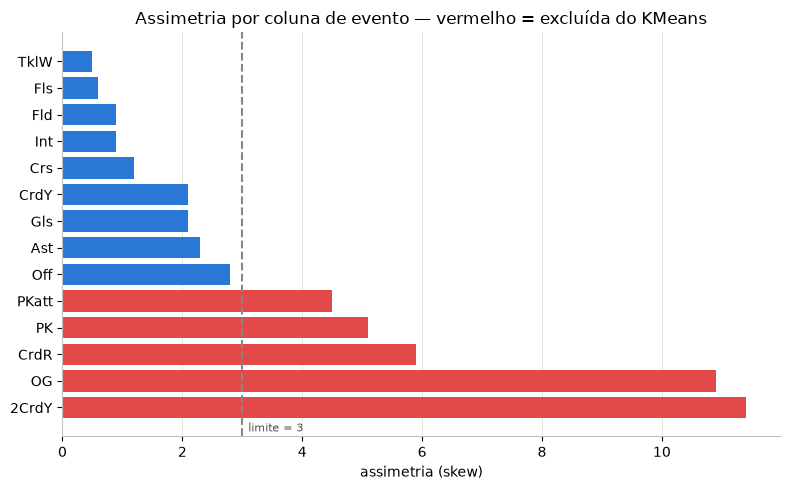

In [226]:
_por90 = stats_df[colunas_evento].div(stats_df['90s'], axis=0)
_z = pd.DataFrame(StandardScaler().fit_transform(_por90), columns=colunas_evento)

diagnostico = pd.DataFrame({
    '% de zeros': (100 * (_por90 == 0).mean()).round(1),
    'assimetria (skew)': _por90.skew().round(1),
    'z-score máximo': _z.abs().max().round(1),
}).sort_values('assimetria (skew)', ascending=False)

diagnostico['classificação'] = np.where(
    diagnostico['assimetria (skew)'] > 3, 'rara -> fora do KMeans', 'mantida'
)

display(diagnostico)

# --- Mesma informação em gráfico: skew por coluna, com o limite de 5 marcado ---
cores_diagnostico = diagnostico['classificação'].map(
    {'rara -> fora do KMeans': '#e34948', 'mantida': '#2a78d6'}
)

plt.figure(figsize=(8, 5))
plt.barh(diagnostico.index, diagnostico['assimetria (skew)'], color=cores_diagnostico)
plt.axvline(3, color='#898781', linestyle='--', linewidth=1.5)
plt.text(3.1, -0.9, 'limite = 3', fontsize=8, color='#52514e')
plt.xlabel('assimetria (skew)')
plt.title('Assimetria por coluna de evento — vermelho = excluída do KMeans')

ax = plt.gca()
ax.grid(True, axis='x', color='#e1e0d9', linewidth=0.6)
ax.set_axisbelow(True)
for lado in ('top', 'right'):
    ax.spines[lado].set_visible(False)
for lado in ('left', 'bottom'):
    ax.spines[lado].set_color('#c3c2b7')

plt.tight_layout()
plt.show()

del _por90, _z

In [227]:
colunas_raras = ['PK', 'PKatt', '2CrdY', 'OG', 'CrdR']

colunas_features = [c for c in colunas_evento if c not in colunas_raras]

print(f'{len(colunas_features)} features no KMeans: {colunas_features}')

9 features no KMeans: ['Gls', 'Ast', 'CrdY', 'Fls', 'Fld', 'Off', 'Crs', 'Int', 'TklW']


In [228]:
stats_df[colunas_evento] = stats_df[colunas_evento].div(stats_df['90s'], axis=0).round(2)

#### Retirando os goleiros

In [229]:
stats_df = stats_df[stats_df['Pos'] != 'GK']

### Aplicando o StandardScaler

In [230]:
X = stats_df[colunas_features]
y = stats_df[coluna_target]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### PCA

In [231]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
variancia = 100 * pca.explained_variance_ratio_

print(f'PC1: {variancia[0]:.1f}%  |  PC2: {variancia[1]:.1f}%')
print(f'Variância representada no plano PC1 x PC2: {variancia.sum():.1f}%')

PC1: 27.6%  |  PC2: 18.8%
Variância representada no plano PC1 x PC2: 46.4%


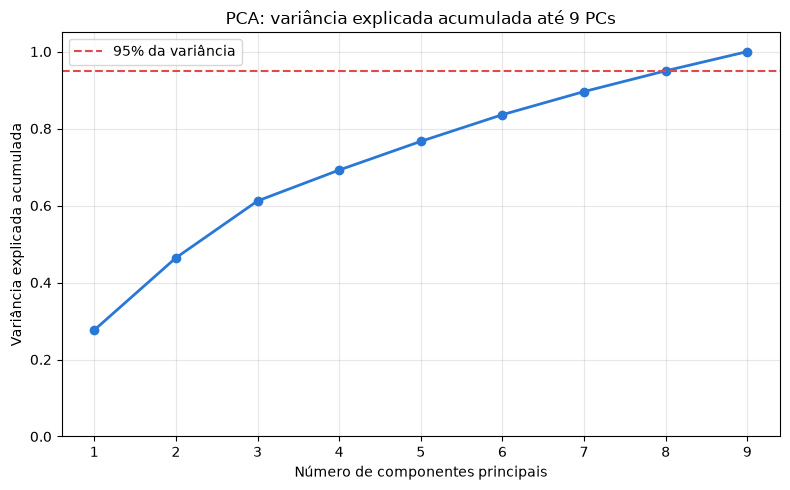

In [232]:
### Variância explicada acumulada por todas as componentes principais

k = X_scaled.shape[1]  # uma PC por feature em colunas_features

pca_k = PCA(n_components=k)
pca_k.fit(X_scaled)

variancia_acumulada = np.cumsum(pca_k.explained_variance_ratio_)

plt.figure(figsize=(8, 5))
plt.plot(
    range(1, k + 1),
    variancia_acumulada,
    marker='o',
    color='#2a78d6',
    linewidth=2
)

plt.axhline(
    0.95,
    color='#e34948',
    linestyle='--',
    linewidth=1.5,
    label='95% da variância'
)

plt.xticks(range(1, k + 1))
plt.ylim(0, 1.05)
plt.xlabel('Número de componentes principais')
plt.ylabel('Variância explicada acumulada')
plt.title(f'PCA: variância explicada acumulada até {k} PCs')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### Aplicando o Kmeans e escolhendo o K

In [233]:
valores_k = range(2, 11)
inercias = []

for k in valores_k:
    km = KMeans(n_clusters=k, n_init=20, random_state=42)
    km.fit(X_scaled)
    inercias.append(km.inertia_)

metricas = pd.DataFrame({
    'k': list(valores_k),
    'inercia': inercias,
})

display(metricas.round(3))

,k,inercia
0,2,4054.568
1,3,3634.892
2,4,3250.033
3,5,3073.050
4,6,2913.017
5,7,2755.271
6,8,2635.581
7,9,2545.774
8,10,2461.875


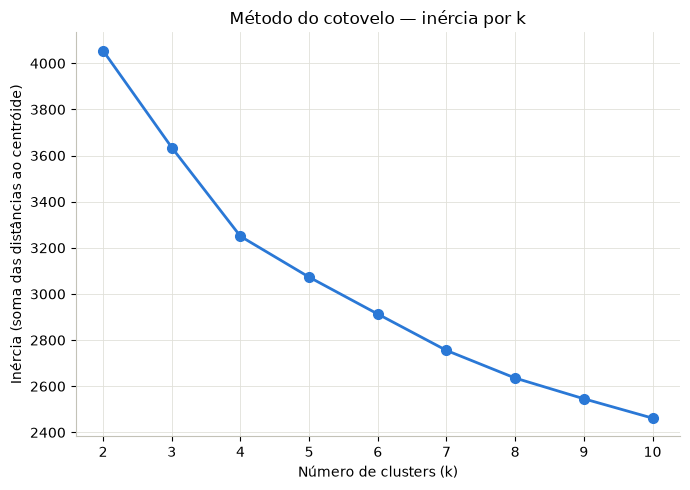

In [234]:
### Método do cotovelo: procure o k onde a queda da inércia desacelera — dali pra frente,
### cada cluster a mais compra pouca redução de distância.

plt.figure(figsize=(7, 5))
plt.plot(metricas['k'], metricas['inercia'],
         marker='o', markersize=7, color='#2a78d6', linewidth=2)
plt.title('Método do cotovelo — inércia por k')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Inércia (soma das distâncias ao centróide)')
plt.xticks(list(valores_k))

ax = plt.gca()
ax.grid(True, color='#e1e0d9', linewidth=0.6)
ax.set_axisbelow(True)
for lado in ('top', 'right'):
    ax.spines[lado].set_visible(False)
for lado in ('left', 'bottom'):
    ax.spines[lado].set_color('#c3c2b7')

plt.tight_layout()
plt.show()

In [235]:
k_escolhido = 4

kmeans = KMeans(n_clusters=k_escolhido, n_init=20, random_state=42)
clusters_kmeans = kmeans.fit_predict(X_scaled)

print(f'k = {k_escolhido}')
print(pd.Series(clusters_kmeans).value_counts().sort_index().to_string())

k = 4
0     95
1    143
2    119
3    205


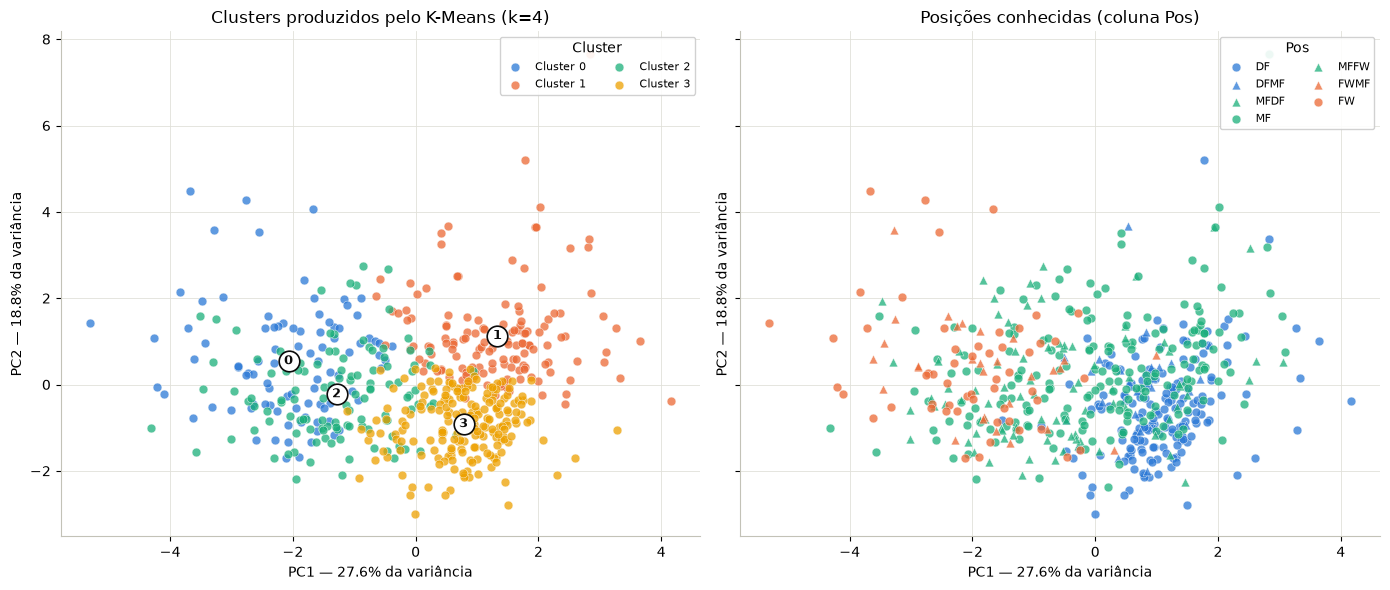

k = 4  |  variância representada no plano: 46.4%


cluster,0,1,2,3
Pos,,,,
DF,0,39,13,118
DFMF,0,13,3,12
MFDF,0,12,3,11
MF,12,73,56,52
MFFW,17,4,33,7
FWMF,18,1,9,1
FW,48,1,2,4


cluster,0,1,2,3
Pos,,,,
DF,0.0,22.9,7.6,69.4
DFMF,0.0,46.4,10.7,42.9
MFDF,0.0,46.2,11.5,42.3
MF,6.2,37.8,29.0,26.9
MFFW,27.9,6.6,54.1,11.5
FWMF,62.1,3.4,31.0,3.4
FW,87.3,1.8,3.6,7.3


In [236]:
### A nuvem projetada em PC1 x PC2, colorida duas vezes: por cluster e por Pos real.
### Virou função porque vamos olhar o mesmo par de gráficos para vários k.

pos = stats_df['Pos'].to_numpy()

# A cor identifica o grupo, mas nunca sozinha: no painel 1 os centróides são
# rotulados (se k > 8 as cores se repetem, o número é que dá a identidade);
# no painel 2 o marcador separa posição pura de híbrida.
cores_cluster = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100',
                 '#e87ba4', '#008300', '#4a3aa7', '#e34948']
cores_pos = {'GK': '#4a3aa7', 'DF': '#2a78d6', 'MF': '#1baf7a', 'FW': '#eb6834'}
ordem_pos = ['GK', 'DF', 'DFMF', 'MFDF', 'MF', 'MFFW', 'FWMF', 'FW']


def comparar_clusters_vs_pos(k):
    km = KMeans(n_clusters=k, n_init=20, random_state=42)
    rotulos = km.fit_predict(X_scaled)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

    # --- Painel 1: clusters produzidos pelo K-Means ---
    for c in np.unique(rotulos):
        plot = rotulos == c
        axes[0].scatter(
            X_pca[plot, 0], X_pca[plot, 1],
            color=cores_cluster[c % len(cores_cluster)], label=f'Cluster {c}',
            alpha=0.75, s=40, edgecolors='#fcfcfb', linewidths=0.4
        )

    for c, (cx, cy) in enumerate(pca.transform(km.cluster_centers_)):
        axes[0].scatter(cx, cy, s=220, color='white',
                        edgecolors='#0b0b0b', linewidths=1.2, zorder=5)
        axes[0].text(cx, cy, str(c), ha='center', va='center',
                     fontsize=9, fontweight='bold', color='#0b0b0b', zorder=6)

    axes[0].set_title(f'Clusters produzidos pelo K-Means (k={k})')
    axes[0].legend(title='Cluster', fontsize=8, ncol=2, loc='upper right', framealpha=0.9)

    # --- Painel 2: posições conhecidas ---
    # Cor = posição primária (GK/DF/MF/FW) · marcador = posição pura (o) vs híbrida (^)
    for classe in ordem_pos:
        plot = pos == classe
        if not plot.any():
            continue
        axes[1].scatter(
            X_pca[plot, 0], X_pca[plot, 1],
            color=cores_pos[classe[:2]], marker='^' if len(classe) > 2 else 'o',
            label=classe, alpha=0.75, s=40, edgecolors='#fcfcfb', linewidths=0.4
        )

    axes[1].set_title('Posições conhecidas (coluna Pos)')
    axes[1].legend(title='Pos', fontsize=8, ncol=2, loc='upper right', framealpha=0.9)

    for ax in axes:
        ax.set_xlabel(f'PC1 — {variancia[0]:.1f}% da variância')
        ax.set_ylabel(f'PC2 — {variancia[1]:.1f}% da variância')
        ax.grid(True, color='#e1e0d9', linewidth=0.6)
        ax.set_axisbelow(True)
        for lado in ('top', 'right'):
            ax.spines[lado].set_visible(False)
        for lado in ('left', 'bottom'):
            ax.spines[lado].set_color('#c3c2b7')

    plt.tight_layout()
    plt.show()

    print(f'k = {k}  |  variância representada no plano: {variancia.sum():.1f}%')

    # Contagem absoluta, com Pos nas linhas
    tabela = pd.crosstab(pd.Series(pos, name='Pos'), pd.Series(rotulos, name='cluster'))
    tabela = tabela.reindex([c for c in ordem_pos if c in tabela.index])
    display(tabela)

    # Mesma tabela em % da linha — é aqui que dá para ver quais classes de Pos colapsam
    display((100 * tabela.div(tabela.sum(axis=1), axis=0)).round(1))


comparar_clusters_vs_pos(k_escolhido)

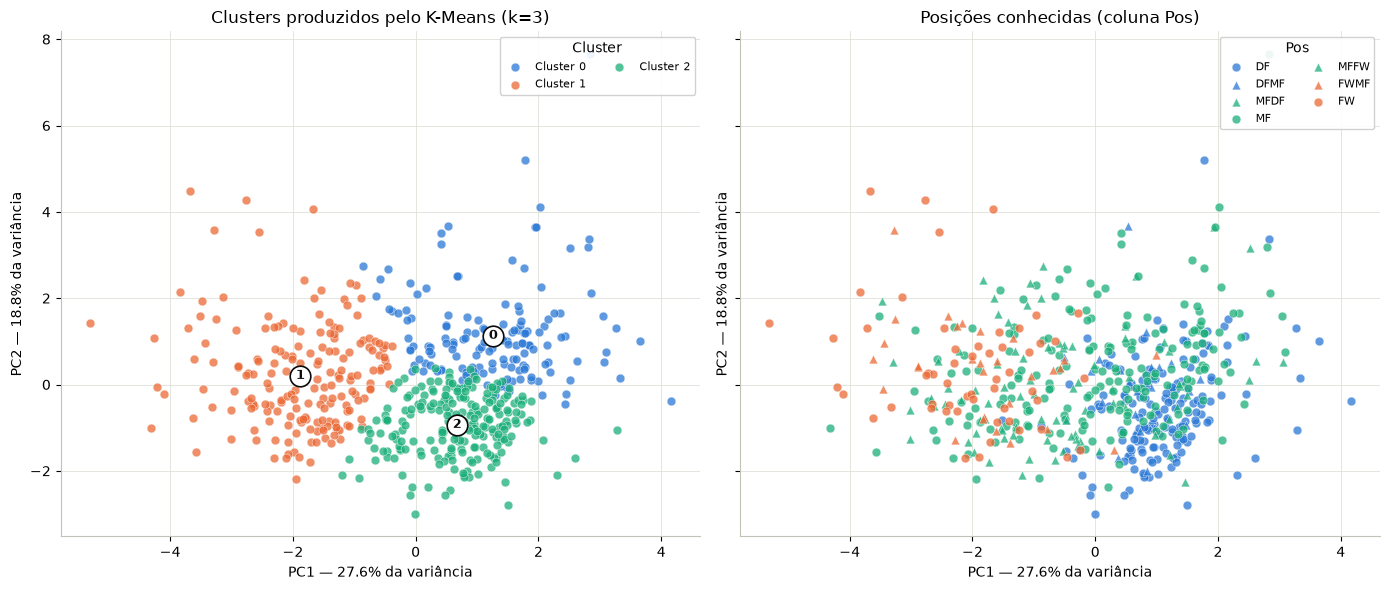

k = 3  |  variância representada no plano: 46.4%


cluster,0,1,2
Pos,,,
DF,42,3,125
DFMF,14,1,13
MFDF,11,0,15
MF,78,60,55
MFFW,5,44,12
FWMF,1,26,2
FW,1,50,4


cluster,0,1,2
Pos,,,
DF,24.7,1.8,73.5
DFMF,50.0,3.6,46.4
MFDF,42.3,0.0,57.7
MF,40.4,31.1,28.5
MFFW,8.2,72.1,19.7
FWMF,3.4,89.7,6.9
FW,1.8,90.9,7.3


In [237]:
comparar_clusters_vs_pos(3)

### Analisando a mediana de minutos dos clusters para ter certeza que não tem um cluster formado essencialmente por reservas (cluster de reservas)

In [238]:
mediana_geral = stats_df['Min'].median()
print(f'mediana de minutos do dataset inteiro: {mediana_geral:.0f}\n')


def perfil_minutagem(k):
    rotulos = KMeans(n_clusters=k, n_init=20, random_state=42).fit_predict(X_scaled)
    agrupado = stats_df.assign(_cluster=rotulos).groupby('_cluster')

    perfil = pd.DataFrame({
        'n': agrupado.size(),
        'Min mediana': agrupado['Min'].median().round(0),
        'razao vs geral': (agrupado['Min'].median() / mediana_geral).round(2),
        '% abaixo de 450min': (100 * agrupado['Min'].apply(lambda s: (s < 450).mean())).round(1),
        'Pos dominante': agrupado['Pos'].agg(lambda s: s.mode()[0]),
    })
    perfil.index.name = f'cluster (k={k})'

    return perfil.sort_values('Min mediana')


for k_teste in [3, 4, 5]:
    display(perfil_minutagem(k_teste))

mediana de minutos do dataset inteiro: 1038



,n,Min mediana,razao vs geral,% abaixo de 450min,Pos dominante
cluster (k=3),,,,,
0,152,974.0,0.94,22.4,MF
1,184,1068.0,1.03,18.5,MF
2,226,1090.0,1.05,21.7,DF


,n,Min mediana,razao vs geral,% abaixo de 450min,Pos dominante
cluster (k=4),,,,,
0,95,961.0,0.93,21.1,FW
1,143,965.0,0.93,21.7,MF
2,119,1028.0,0.99,16.8,MF
3,205,1124.0,1.08,22.4,DF


,n,Min mediana,razao vs geral,% abaixo de 450min,Pos dominante
cluster (k=5),,,,,
0,53,821.0,0.79,28.3,MF
4,106,882.0,0.85,22.6,MF
3,98,1048.0,1.01,19.4,FW
1,175,1124.0,1.08,24.6,DF
2,130,1206.0,1.16,12.3,MF
